ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, we use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

We use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

Import the libraries needed for data analysis, visualization, preprocessing, clustering, and evaluation.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Get the Data

Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

**Check summary statistics using `describe()`.**

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
df.drop(columns=['CUST_ID'], inplace=True)

**Check the missing values in each column.**

In [8]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Some columns contain missing values.

- `MINIMUM_PAYMENTS`: 313 missing values  
- `CREDIT_LIMIT`: 1 missing value  

We handle these using **mean imputation** — filling each missing value with the mean of its column.

**Fill the missing values with the mean of each column.**

In [9]:
df.fillna(df.mean(), inplace=True)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,864.206542,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


**Check the missing values again to make sure they were handled.**

In [10]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

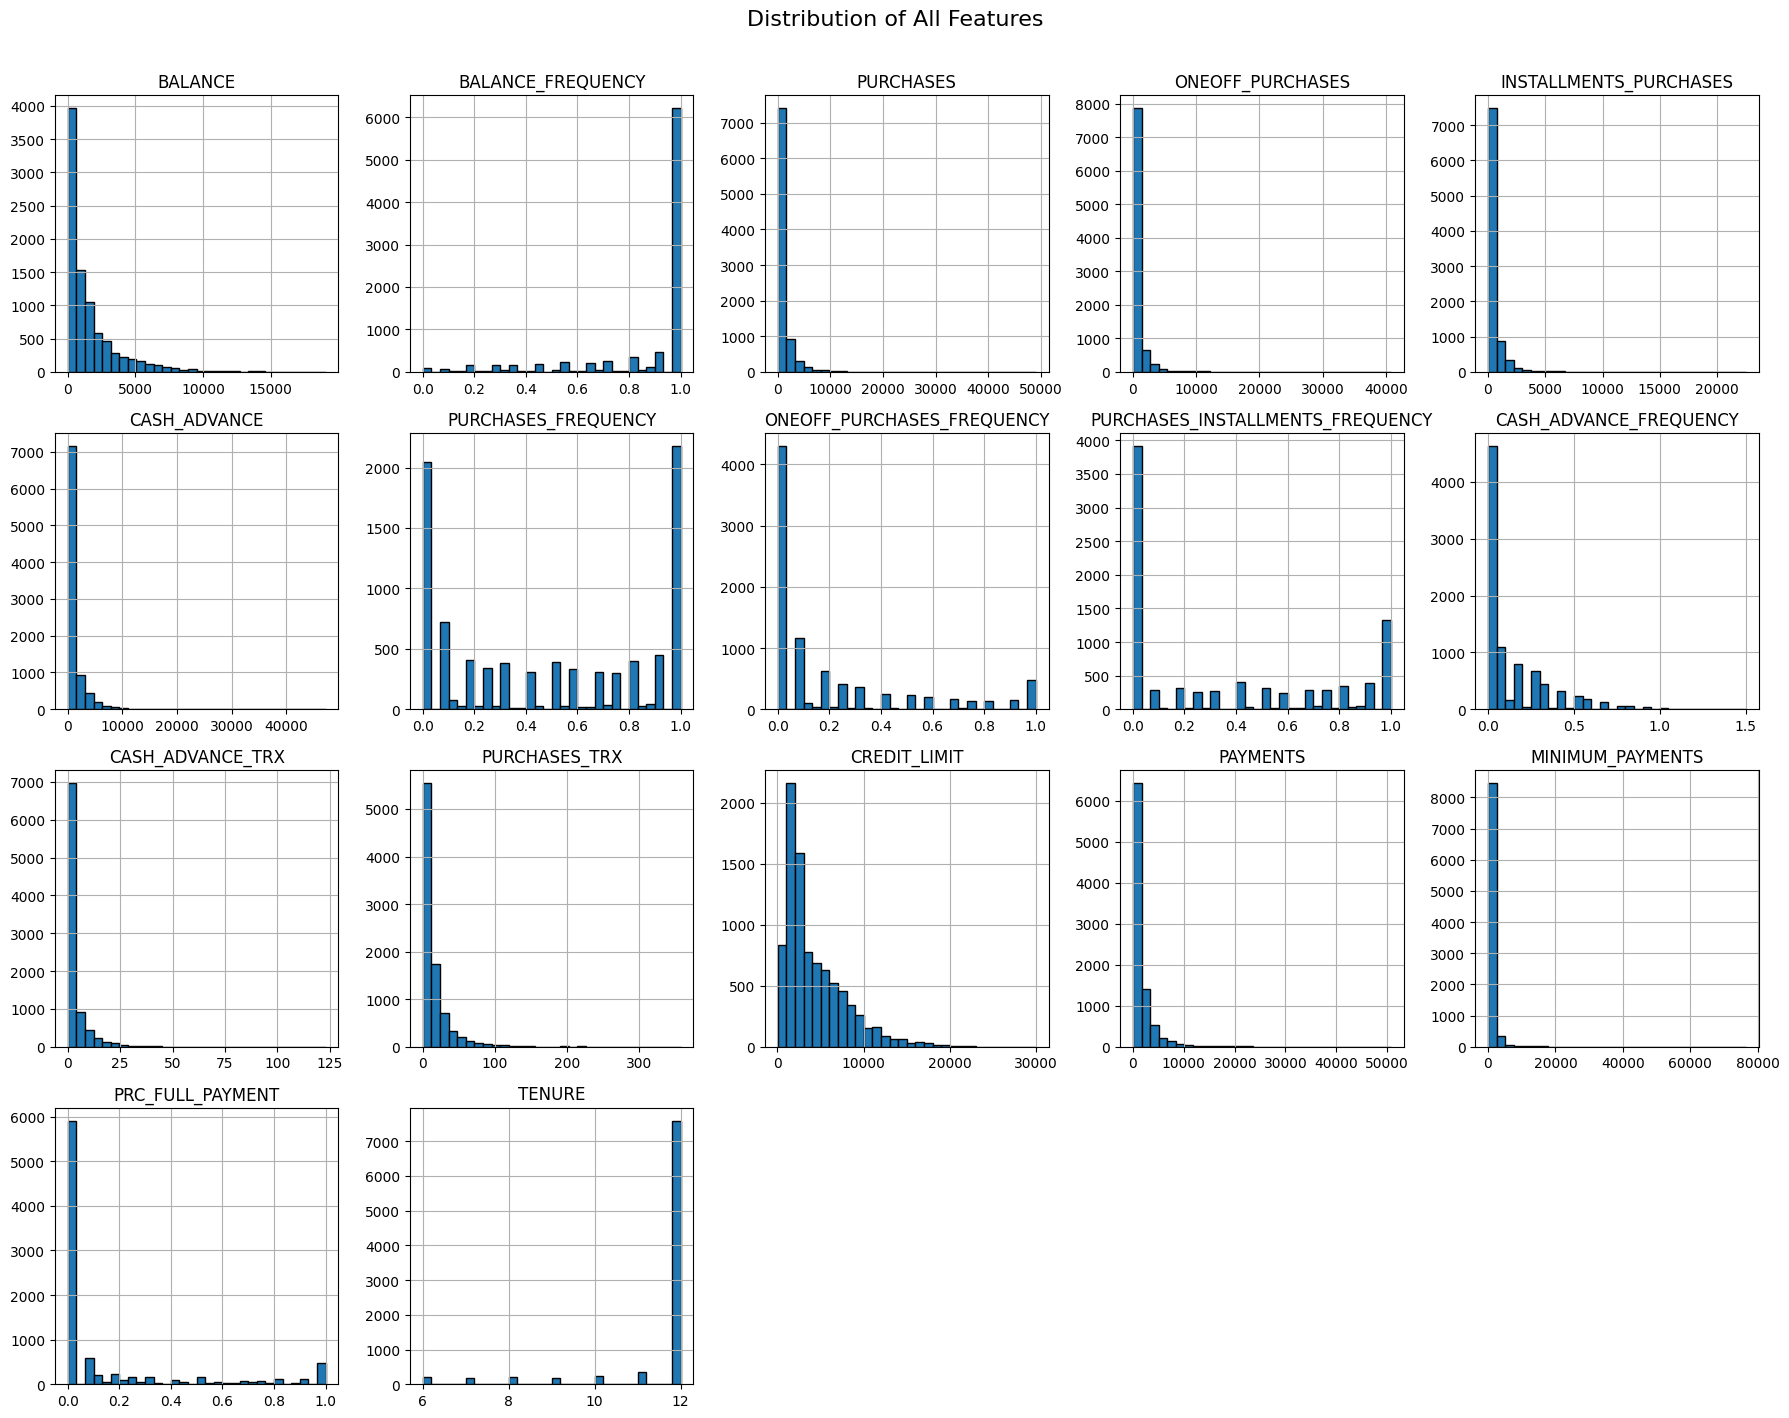

In [11]:
df.hist(figsize=(18, 14), bins=30, layout=(4, 5), edgecolor='black')
plt.suptitle('Distribution of All Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

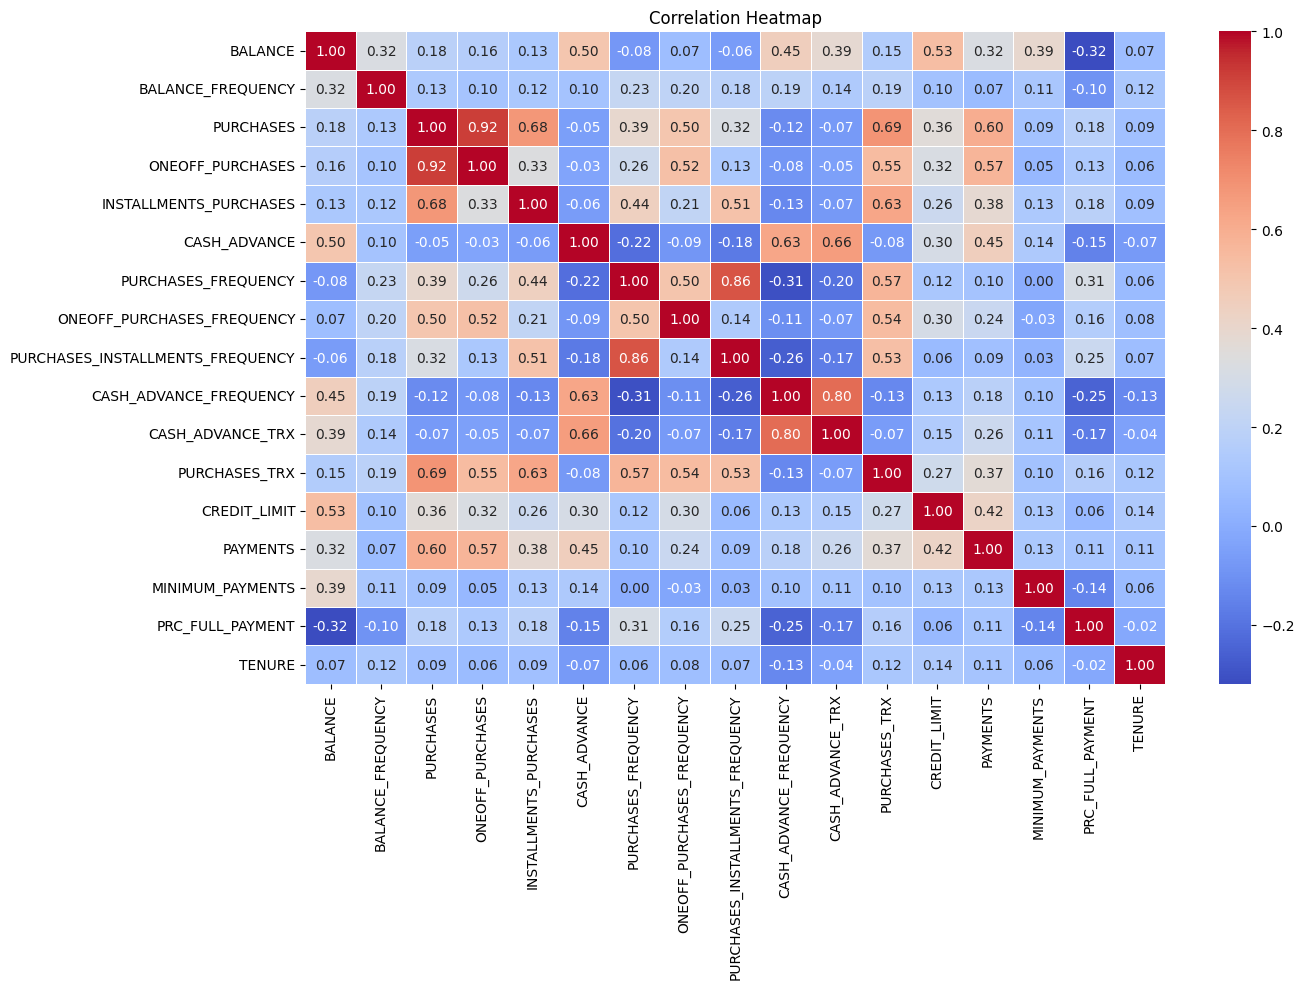

In [12]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

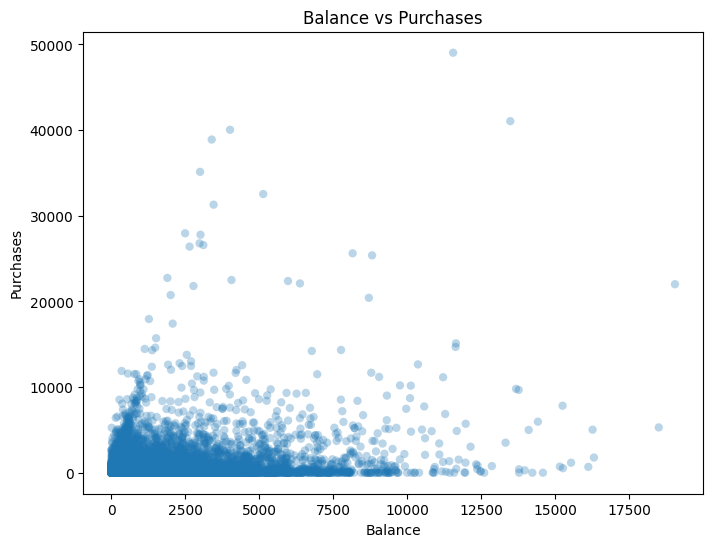

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, edgecolors='none')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('Balance vs Purchases')
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

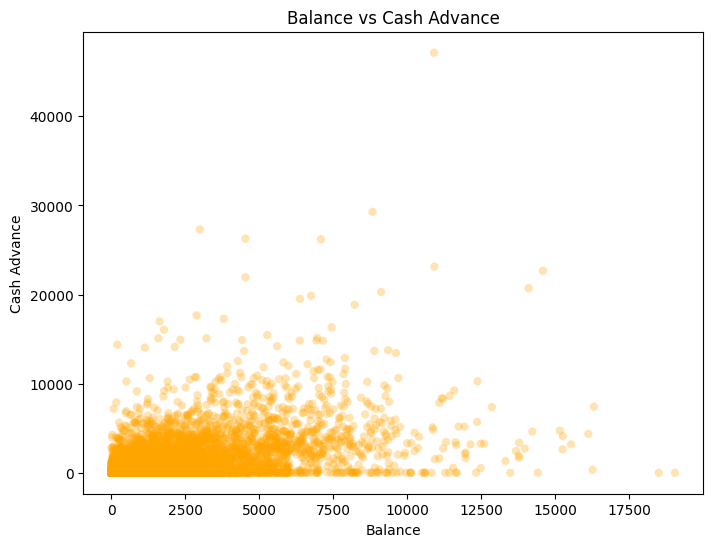

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, color='orange', edgecolors='none')
plt.xlabel('Balance')
plt.ylabel('Cash Advance')
plt.title('Balance vs Cash Advance')
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Shape of X_scaled:", X_scaled.shape)
print("First row sample:", X_scaled[0])

Shape of X_scaled: (8950, 17)
First row sample: [-0.73198937 -0.24943448 -0.42489974 -0.35693402 -0.34907882 -0.46678555
 -0.80649035 -0.67866081 -0.70731317 -0.67534886 -0.47606982 -0.51133325
 -0.96043334 -0.52897879 -0.31096755 -0.52555097  0.36067954]


## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [16]:
inertia_values = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

**Plot the elbow curve.**

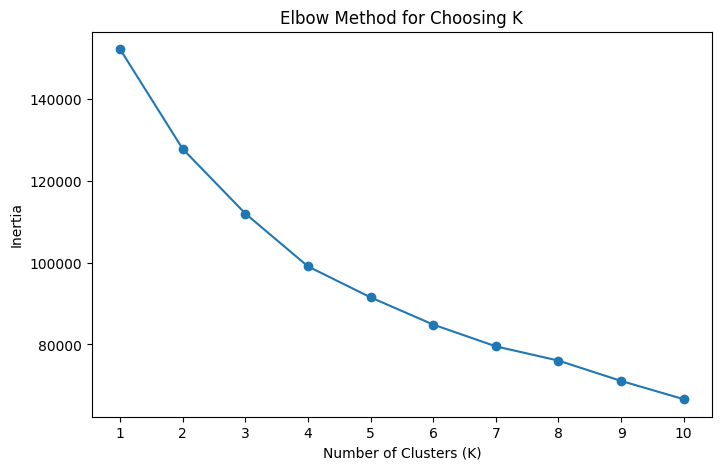

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing K')
plt.xticks(K_range)
plt.show()

**Output Interpretation**

The elbow curve shows how inertia decreases as K increases. We look for the point where the curve starts to flatten — that is the "elbow". Based on this plot, the decrease slows noticeably around **K = 4 or K = 5**, suggesting one of those values may be a reasonable choice.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [27]:
silhouette_scores = []

K_range_sil = range(2, 11)

for k in K_range_sil:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

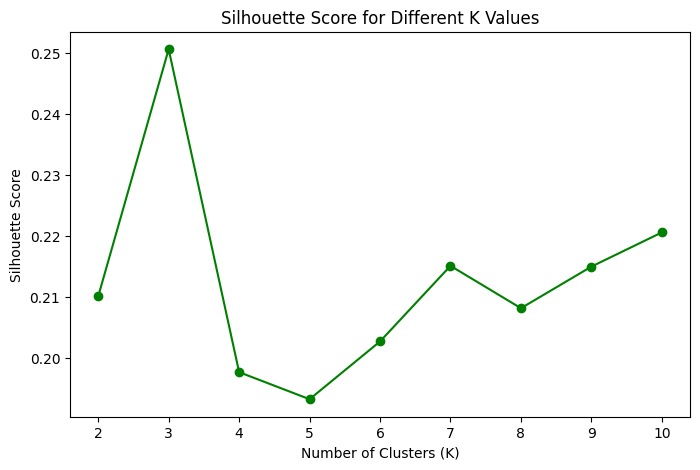

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(K_range_sil, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(K_range_sil)
plt.show()

**Create a table showing each K value and its silhouette score.**

In [29]:
score_table = pd.DataFrame({
    'K': list(K_range_sil),
    'Silhouette Score': silhouette_scores
})

score_table

,K,Silhouette Score
0,2,0.210033
1,3,0.250556
2,4,0.197607
3,5,0.193169
4,6,0.202639
5,7,0.215038
6,8,0.208092
7,9,0.214912
8,10,0.220518


**Output Interpretation**

A higher silhouette score indicates better-separated clusters. K = 2 often gives the highest silhouette score mathematically, but it may be too coarse for business use. We balance the score with interpretability and the elbow curve, leading us to choose **K = 3** as a practical and meaningful segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

We choose **K = 3** because:
- The elbow curve shows that inertia improvement slows noticeably after K = 3.
- The silhouette score is highest at K = 3 (≈ 0.25), confirming this is the best-separated clustering.
- Three clusters also provides clear and interpretable business segments.

Use `random_state=42` and `n_init=10`.

In [21]:
final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
final_model.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [22]:
df['Cluster'] = final_model.labels_

**Check the first five rows after adding the cluster labels.**

In [23]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [24]:
cluster_summary = df.groupby('Cluster').mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3989.326804,0.957980,384.528277,248.718133,135.887632,3869.856855,0.232290,0.110942,0.144242,0.447176,12.390351,5.612155,6682.960242,3018.907202,1795.687341,0.033774,11.350877
1,2220.003291,0.981477,4268.520980,2717.828543,1551.178267,458.421147,0.949093,0.668166,0.744584,0.063014,1.528745,56.472065,7733.967611,4151.276172,1224.538588,0.298632,11.923077
2,799.702576,0.835188,505.532394,253.120131,252.733061,329.866776,0.465072,0.132333,0.345145,0.068316,1.211636,8.653865,3269.793763,909.729614,548.525315,0.155750,11.478836


**Check how many customers are in each cluster.**

Cluster
0    1596
1    1235
2    6119
Name: count, dtype: int64


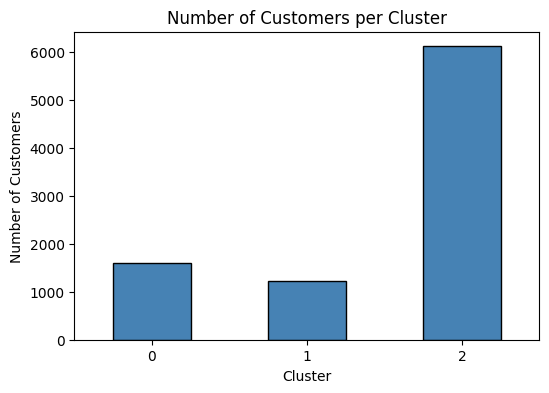

In [25]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)

plt.figure(figsize=(6, 4))
cluster_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)
plt.show()

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

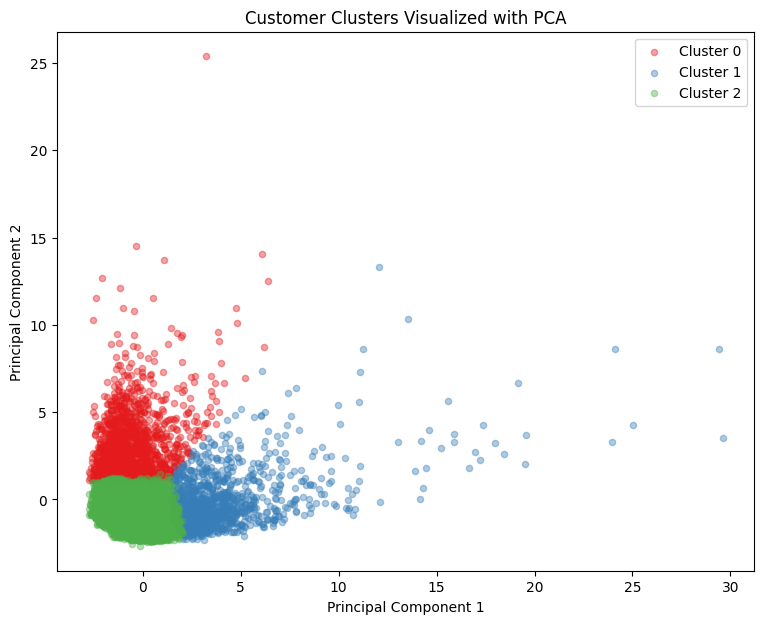

Variance explained by PC1: 27.3%
Variance explained by PC2: 20.3%


In [26]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].values

plt.figure(figsize=(9, 7))
colors = ['#e41a1c', '#377eb8', '#4daf4a']
for cluster_id in sorted(pca_df['Cluster'].unique()):
    subset = pca_df[pca_df['Cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster_id}',
                alpha=0.4, s=20, color=colors[cluster_id])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Clusters Visualized with PCA')
plt.legend()
plt.show()

explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]*100:.1f}%")
print(f"Variance explained by PC2: {explained[1]*100:.1f}%")

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters. If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

**1. Why is this an unsupervised learning problem?**

This is an unsupervised learning problem because the dataset does not contain a target label or pre-defined customer groups. There is no column that says which segment a customer belongs to. The algorithm discovers patterns on its own.

**2. Why did we remove the `CUST_ID` column?**

`CUST_ID` is a unique identifier for each customer. It carries no behavioral information. Including it would not help the model find meaningful patterns and could interfere with distance calculations.

**3. Which columns had missing values?**

- `MINIMUM_PAYMENTS`: 313 missing values  
- `CREDIT_LIMIT`: 1 missing value

**4. How did you handle the missing values?**

We used mean imputation: `df.fillna(df.mean(), inplace=True)`. Each missing value was replaced with the average value of its column. This preserves the dataset size without significantly distorting distributions.

**5. Why is scaling important before applying K-Means?**

K-Means measures distance between data points. Without scaling, features with large ranges (like `BALANCE` or `CREDIT_LIMIT`, which can be in the thousands) dominate over features with small ranges (like frequency columns between 0 and 1). StandardScaler puts all features on the same scale so each one contributes equally.

**6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.**

We chose **K = 3**.  
- The elbow curve shows a visible bend around K = 3, where the inertia improvement begins to slow down significantly.  
- The silhouette score is highest at K = 3 (≈ 0.25), which confirms that clusters are most clearly separated at this value compared to all other K values tested.

**7. Based on the cluster summary table, describe each customer segment in your own words.**

- **Cluster 0 — Cash Advance Users**: Very high balance (~$3,989) and the highest cash advance usage (~$3,870). They rarely make purchases and almost never pay in full. These customers rely heavily on the credit card for cash borrowing rather than spending.
- **Cluster 1 — High-Value Active Purchasers**: The highest purchases (~$4,269), highest credit limit (~$7,734), and highest payments (~$4,151). They shop frequently and pay off most of their balance. These are the most financially active and reliable customers.
- **Cluster 2 — Low-Activity Average Users**: Lowest balance (~$800), modest purchases (~$506), and minimal cash advance. These customers use their card occasionally and represent the average or inactive segment.

**8. Which cluster may represent high-value customers?**

**Cluster 1** represents high-value customers. They have the highest purchases, the highest credit limit, and the highest payments. They spend frequently and repay reliably, making them the most profitable and desirable customer segment.

**9. Which cluster may represent customers who rely more on cash advance?**

**Cluster 0** represents cash-advance-dependent customers. They have the highest cash advance amount (~$3,870) and the highest cash advance frequency (0.45), but very low purchase activity. They use the card primarily for borrowing cash rather than spending.

**10. How can a company use these clusters for marketing strategy?**

- **Cluster 1 (High-Value Purchasers)**: Offer premium rewards, cashback programs, and exclusive benefits to retain them and increase loyalty.
- **Cluster 0 (Cash Advance Users)**: Offer debt management tools, flexible repayment plans, or credit counseling. Monitor this segment for credit risk.
- **Cluster 2 (Low-Activity Users)**: Send re-engagement campaigns with introductory spending rewards or limited-time offers to encourage more card usage.